In [1]:
from pathlib import Path
import sys
import litellm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from statistics import mean

# Add the repo root to sys.path so we can import our modules
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GenerateKeywordCards2.swow import get_swow_rows
from GenerateKeywordCards2.swow import SWOWAssociations

from GenerateKeywordCards2.embeddings import (
    WordEmbeddings,
    compare_with_swow,
    summarize_swow_comparisons,
)

In [2]:
litellm.cache = litellm.Cache(type="disk")


def get_cache_count() -> int:
    disk_cache_object = litellm.cache.cache.disk_cache
    return len(disk_cache_object)


initial_cache_count = get_cache_count()

# SWOW word association dataset

In [3]:
rows = get_swow_rows()
print(f"{len(rows):,} rows")
for row in rows[:5]:
    row_str = ", ".join(f"{k}={v}" for k, v in row.items())
    print(row_str)

Using cached SWOW data/workspaces/SoCloverAI/GenerateKeywordCards2/cache/SWOW-EN.complete.20180827.csv
1,356,362 rows
=1, id=1500428, participantID=130332, created_at=2018-01-07 04:29:38, age=61, nativeLanguage=United States, gender=Ma, education=5, city=Pepperell, country=United States, section=seed, cue=there, R1Raw=position, R2Raw=place, R3Raw=point, R1=position, R2=place, R3=point
=2, id=1500426, participantID=130332, created_at=2018-01-07 04:29:38, age=61, nativeLanguage=United States, gender=Ma, education=5, city=Pepperell, country=United States, section=seed, cue=true, R1Raw=honest, R2Raw=fact, R3Raw=indisputable, R1=honest, R2=fact, R3=indisputable
=3, id=1500424, participantID=130332, created_at=2018-01-07 04:29:38, age=61, nativeLanguage=United States, gender=Ma, education=5, city=Pepperell, country=United States, section=seed, cue=beat, R1Raw=drum, R2Raw=policeman, R3Raw=beatnik, R1=drum, R2=policeman, R3=beatnik
=4, id=1500438, participantID=130332, created_at=2018-01-07 04

In [4]:
print("Corrections to the raw data:")
maximum_corrections_to_list = 25
corrections_count = 0
for row in rows:
    if row["R1Raw"] != row["R1"]:
        print(f"{row['R1Raw']} -> {row['R1']}")
        corrections_count += 1
    if row["R2Raw"] != row["R2"]:
        print(f"{row['R2Raw']} -> {row['R2']}")
        corrections_count += 1
    if row["R3Raw"] != row["R3"]:
        print(f"{row['R3Raw']} -> {row['R3']}")
        corrections_count += 1
    if corrections_count >= maximum_corrections_to_list:
        print(f"Maximum corrections to list ({maximum_corrections_to_list}) reached.")
        break


Corrections to the raw data:
hamdset -> handset
bounf -> bound
american -> American
shrek -> shriek
stident -> student
january -> January
colourless -> colorless
honour -> honor
satan -> Satan
aswell -> as well
abc -> ABC
marvellous -> marvelous
hard labour -> hard labor
labour -> labor
prime mimister -> prime minister
abc -> ABC
dtuy -> duty
Book -> book
Thesis -> thesis
lord of the rings -> Lord of the Rings
In relation to something -> in relation to something
Nearly -> nearly
Not quite -> not quite
In addition to -> in addition to
Abusive -> abusive
Not light handed -> not light handed
Maximum corrections to list (25) reached.


In [5]:
swow = SWOWAssociations()
print(list(swow.associations.keys())[:20])

Using cached SWOW data/workspaces/SoCloverAI/GenerateKeywordCards2/cache/SWOW-EN.complete.20180827.csv
['there', 'position', 'place', 'point', 'true', 'honest', 'fact', 'indisputable', 'beat', 'drum', 'policeman', 'beatnik', 'like', 'affection', 'simile', 'compare', 'telephone', 'receiver', 'handset', 'wires']


In [6]:
print("cat forward associations:")
print(swow.associations["cat"].forward)
print("cat backward associations:")
print(swow.associations["cat"].backward)
print("dog forward associations:")
print(swow.associations["dog"].forward)
print("dog backward associations:")
print(swow.associations["dog"].backward)

cat forward associations:
{'dog': 65, 'feline': 24, 'meow': 17, 'mouse': 14, 'purr': 13, 'fur': 10, 'pet': 9, 'animal': 8, 'soft': 7, 'kitten': 7, 'furry': 6, 'pussy': 6, 'kitty': 5, 'tiger': 5, 'lion': 4, 'hair': 4, 'nap': 4, 'purring': 3, 'scratch': 3, 'black': 3, 'cute': 3, 'Tabby': 3, 'fluffy': 3, 'claws': 3, 'litter': 3, 'house': 2, 'nip': 2, 'category': 2, 'tail': 2, 'cuddly': 2, 'whiskers': 2, 'bitch': 2, 'warm': 2, 'sneaky': 2, 'allergy': 2, 'love': 2, 'hat': 2, 'sat': 2, 'mat': 2, 'fish': 2, 'aloof': 2, 'catwalk': 1, 'predator': 1, 'mice': 1, 'annoying': 1, 'Facebook': 1, 'nuisance': 1, 'chow': 1, 'face': 1, 'hipster': 1, 'machine': 1, 'lovable': 1, 'type of animal': 1, 'fool around': 1, 'burglar': 1, 'adorable': 1, 'box': 1, 'leopard': 1, 'friendly': 1, 'lady': 1, 'crazy': 1, 'bed': 1, 'whisker': 1, 'tin roof': 1, 'o nine tails': 1, 'slippery': 1, 'bitchy': 1, 'strophe': 1, 'paw': 1, 'erpillar': 1, 'carnivore': 1, 'Cheshire': 1, 'puss': 1, 'cuddle': 1, 'Harriet': 1, 'bogus': 

In [7]:
# Multi-word phrases such as "No more responses" and "Unkown word" can indicate null values. Make sure we've filtered those out.
multi_word_backward_association_counts = {word: sum(associations.backward.values()) for word, associations in swow.associations.items() if " " in word}
min_multi_word_backward_association_count = 20
multi_word_backward_association_counts = {word: count for word, count in multi_word_backward_association_counts.items() if count >= min_multi_word_backward_association_count}
sorted_multi_word_backward_association_counts = sorted(multi_word_backward_association_counts.items(), key=lambda x: x[1], reverse=True)
print(
    f"Multi-word backward association counts (min {min_multi_word_backward_association_count}):"
)
for word, count in sorted_multi_word_backward_association_counts:
    print(f"  {word}: {count}")

Multi-word backward association counts (min 20):
  ice cream: 1281
  New York: 549
  give up: 542
  high school: 470
  a lot: 462
  Harry Potter: 446
  too much: 410
  light bulb: 311
  United States: 307
  old fashioned: 288
  hard work: 265
  black and white: 264
  video game: 251
  make up: 246
  Star Trek: 238
  Wall Street: 232
  Star Wars: 228
  hot dog: 224
  take away: 214
  give in: 204
  TV show: 198
  roller coaster: 193
  Middle East: 191
  peanut butter: 190
  next to: 188
  thank you: 186
  fast food: 180
  stuck up: 176
  South America: 172
  old man: 172
  let go: 171
  throw away: 170
  video games: 164
  well done: 161
  belly button: 155
  credit card: 152
  not enough: 152
  in charge: 151
  on time: 151
  Lord of the Rings: 149
  hold back: 147
  Native American: 142
  of course: 139
  put down: 138
  New Orleans: 136
  Middle Ages: 136
  World War II: 133
  science fiction: 130
  outer space: 125
  global warming: 124
  put together: 123
  solar system: 121
  put 

Total words: 166541
0 words with no associations: []

137 / 12,291 words with Forward associations have no Backward associations: ['there', 'position', 'place', 'point', 'true', 'honest', 'fact', 'beat', 'drum', 'policeman', 'like', 'affection', 'simile', 'compare', 'telephone', 'receiver', 'wires', 'beauty', 'awe', 'pretty', 'longing', 'Mrs', 'wife', 'married', 'strong', 'test', 'grade', 'trial', 'exam', 'waste', 'trash', 'careless', 'bin', 'language', 'speech', 'study', 'communicate', 'post', 'mail', 'fence', 'wonder', 'ponder', 'muse', 'dad', 'father', 'love', 'just', 'separate', 'apart', 'split', 'only', 'limit', 'singular', 'committee', 'group', 'meeting', 'business', 'district', 'area', 'bound', 'boundary', 'pound', 'cake', 'pavement', 'slam', 'traffic', 'car', 'delay', 'grey', 'figure', 'hidden', 'mathematics', 'drawing', 'difficult', 'hard', 'frustrating', 'location', 'building', 'activity', 'future', 'nuclear', 'past', 'present', 'thou', 'thee', 'though', 'vote', 'American', '

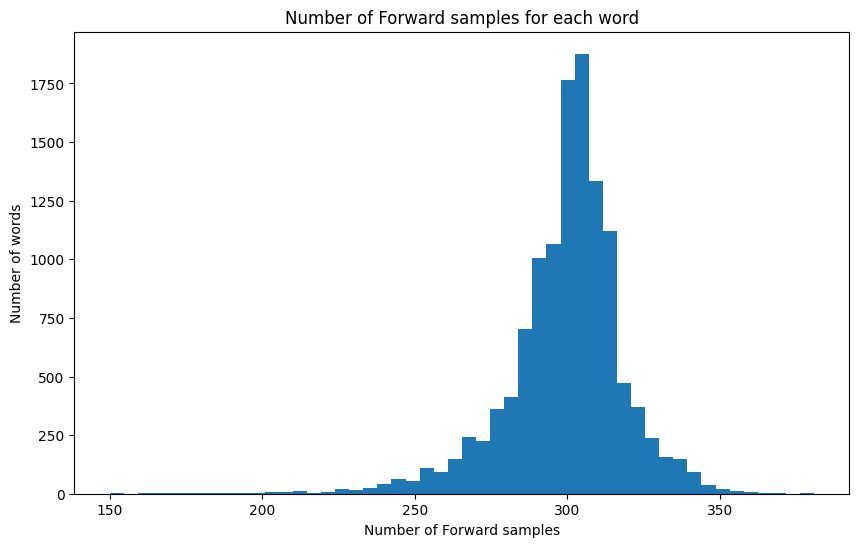

154,250 / 166,404 words with Backward associations have no Forward associations: ['there', 'position', 'place', 'point', 'true', 'honest', 'fact', 'indisputable', 'beat', 'drum', 'policeman', 'beatnik', 'like', 'affection', 'simile', 'compare', 'telephone', 'receiver', 'handset', 'wires', 'beauty', 'awe', 'pretty', 'longing', 'Mrs', 'wife', 'married', 'strong', 'test', 'grade', 'trial', 'exam', 'waste', 'trash', 'careless', 'bin', 'language', 'speech', 'study', 'communicate', 'post', 'guard duty', 'mail', 'fence', 'wonder', 'ponder', 'muse', 'dad', 'father', 'love', 'just', 'upfront', 'separate', 'apart', 'split', 'push away', 'only', 'limit', 'singular', 'committee', 'group', 'meeting', 'business', 'district', 'area', 'bound', 'boundary', 'pound', 'cake', 'pavement', 'slam', 'traffic', 'car', 'delay', 'grey', 'figure', 'hidden', 'mathematics', 'drawing', 'difficult', 'hard', 'laborious', 'frustrating', 'location', 'building', 'activity', 'future', 'nuclear', 'past', 'present', 'thou',

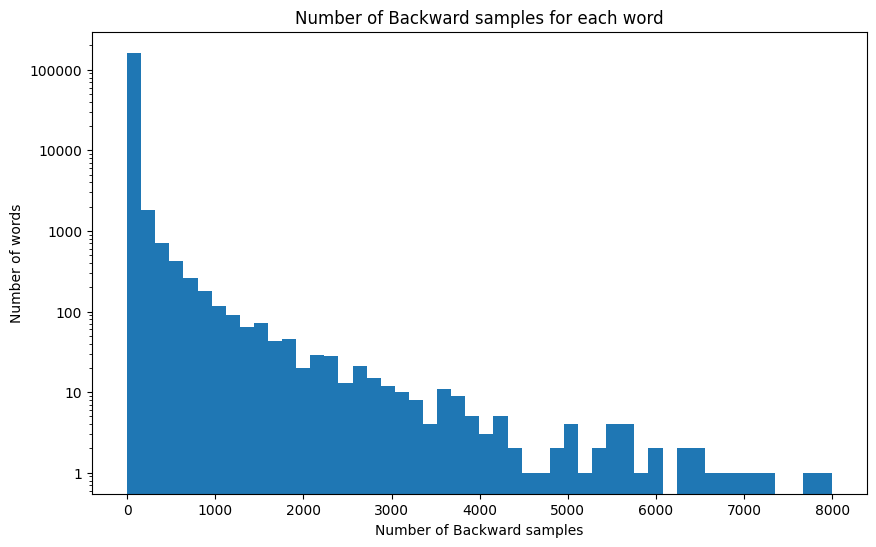

In [8]:
total_words = len(swow.associations)
print(f"Total words: {total_words}")
words_with_no_associations = [word for word, associations in swow.associations.items() if len(associations.forward) == 0 and len(associations.backward) == 0]
print(f"{len(words_with_no_associations)} words with no associations: {words_with_no_associations}")
print()

for forward in [True, False]:
    forward_text = "Forward" if forward else "Backward"
    other_way_text = "Backward" if forward else "Forward"
    words_with_associations = [word for word, associations in swow.associations.items() if len(associations.get_associations(forward, not forward)) > 0]
    words_with_associations_but_not_the_other_way = [word for word, associations in swow.associations.items() if len(associations.get_associations(forward, not forward)) > 0 and len(associations.get_associations(not forward, forward)) == 0]
    print(
        f"{len(words_with_associations_but_not_the_other_way):,} / {len(words_with_associations):,} words with {forward_text} associations have no {other_way_text} associations: {words_with_associations}"
    )

    word_samples = {
        word: sum(
            count
            for _, count in associations.get_associations(forward, not forward).items()
        )
        for word, associations in swow.associations.items()
        if len(associations.get_associations(forward, not forward)) > 0
    }

    min_expected_samples = 150 if forward else 0
    few_samples = {word: count for word, count in word_samples.items() if count < min_expected_samples}
    print(f"{len(few_samples):,} words with few {forward_text} samples (<{min_expected_samples})")
    for word, samples in few_samples.items():
        print(f"  {word} ({samples}): {swow.associations[word].get_associations(forward, not forward)}")

    max_expected_samples = 500 if forward else 8_000
    many_samples = {word: count for word, count in word_samples.items() if count >= max_expected_samples}
    print(f"{len(many_samples):,} words with many {forward_text} samples (>= {max_expected_samples})")
    for word, samples in many_samples.items():
        print(f"  {word} ({samples:,}): {swow.associations[word].get_associations(forward, not forward)}")

    plt.figure(figsize=(10, 6))
    plt.hist([v for v in word_samples.values() if min_expected_samples <= v <= max_expected_samples], bins=50)
    if not forward:
        plt.yscale("log")
        axis = plt.gca()
        for axis_axis in (axis.xaxis, axis.yaxis):
            formatter = ScalarFormatter()
            formatter.set_scientific(False)
            formatter.set_useOffset(False)
            axis_axis.set_major_formatter(formatter)
    plt.xlabel(f'Number of {forward_text} samples')
    plt.ylabel('Number of words')
    plt.title(f'Number of {forward_text} samples for each word')
    plt.show()

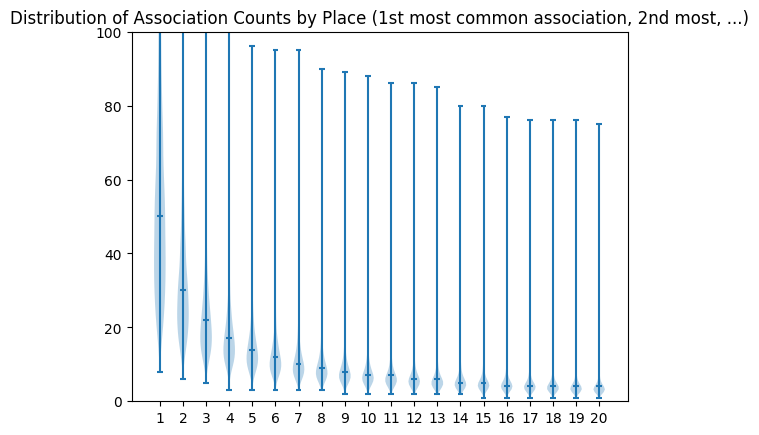

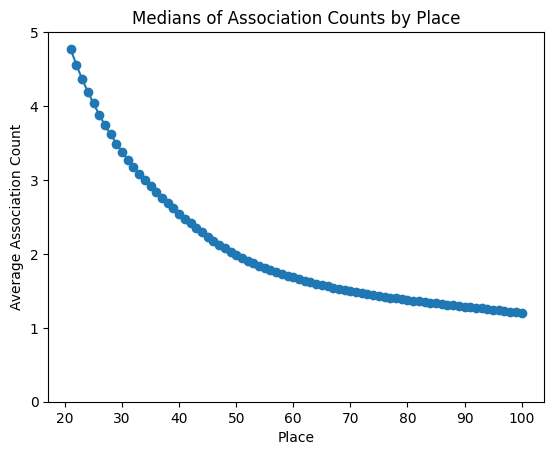

In [9]:
number_of_places = 100
place_counts = [[] for _ in range(number_of_places)]
for word, word_associations in swow.associations.items():
    if len(word_associations.forward) == 0:
        continue
    associations = word_associations.get_associations(True, True)
    association_counts = sorted(associations.values(), reverse=True)[:number_of_places]
    while len(association_counts) < number_of_places:
        association_counts.append(0)
    for i, count in enumerate(association_counts):
        place_counts[i].append(count)

# TODO: Use percentages to normalize for number of sampes of the word
number_of_places_in_chart = 20
plt.title("Distribution of Association Counts by Place (1st most common association, 2nd most, ...)")
plt.violinplot(place_counts[:number_of_places_in_chart], showmedians=True)
plt.xticks(range(1, number_of_places_in_chart + 1))
plt.ylim(0, 100)
plt.show()

place_means = [mean(i) for i in place_counts]
# graph medians after number_of_places_in_chart
plt.title("Medians of Association Counts by Place")
plt.plot(
    range(number_of_places_in_chart + 1, number_of_places + 1),
    place_means[number_of_places_in_chart:],
    marker="o",
)
plt.xlabel("Place")
plt.ylabel("Average Association Count")
plt.yticks(range(0, 5 + 1))
plt.show()


## Embeddings-based associations (via litellm)

Use `GenerateKeywordCards2.embeddings.WordEmbeddings` to:
1. Compare embedding nearest-neighbors against the SWOW human association norms above, to see how well embeddings approximate human associations.
2. Score words with graph-theory-like centrality/diversity metrics to find candidates whose associations span a large, diverse set of other words -- useful for So Clover! keyword expansion.

### Compare embedding neighbors with SWOW human associations

In [10]:
# Build a vocabulary: a handful of cue words plus their SWOW forward responses, plus a
# broader sample of other SWOW words so nearest-neighbor search isn't trivially
# restricted to only the "correct" answers.
sample_cues = ["cat", "dog", "beat", "true", "telephone"]

vocabulary = set(sample_cues)
for cue in sample_cues:
    vocabulary.update(list(swow.associations[cue].forward.keys())[:10])

other_words = list(swow.associations.keys())[:300]
vocabulary.update(other_words)

embedding_models = {
    "openai/text-embedding-3-small",
    "openai/text-embedding-3-large",
    "gemini/gemini-embedding-2",
}
word_embeddings_by_model = {}
for embedding_model in embedding_models:
    word_embeddings, usage = await WordEmbeddings.from_words_async(embedding_model, list(vocabulary))
    word_embeddings_by_model[embedding_model] = word_embeddings
    print(f"* {embedding_model} embedded {len(word_embeddings)} words ({usage})")

* openai/text-embedding-3-small embedded 340 words (340/340 cache hits, $0.0000000 uncached cost, $0.0000091 total cost, 455 prompt tokens)
* openai/text-embedding-3-large embedded 340 words (340/340 cache hits, $0.0000000 uncached cost, $0.0000592 total cost, 455 prompt tokens)
* gemini/gemini-embedding-2 embedded 340 words (340/340 cache hits, $0.0000000 uncached cost, $0.0000910 total cost, 455 prompt tokens)


In [11]:
comparisons = [
    compare_with_swow(word_embeddings_by_model["openai/text-embedding-3-small"], swow, cue, count=10)
    for cue in sample_cues
]
for comparison in comparisons:
    print(f"{comparison.word}: embedding neighbors = {comparison.embedding_neighbors}")
    print(f"{' ' * len(comparison.word)}  swow responses    = {comparison.swow_responses}")
    print(
        f"{' ' * len(comparison.word)}  overlap = {comparison.overlap} (jaccard={comparison.jaccard:.2f})"
    )

print(summarize_swow_comparisons(comparisons))

cat: embedding neighbors = ['feline', 'dog', 'animal', 'pet', 'kitten', 'meow', 'purr', 'car', 'child', 'mouse']
     swow responses    = ['dog', 'feline', 'meow', 'mouse', 'purr', 'fur', 'pet', 'animal', 'soft', 'kitten']
     overlap = ['feline', 'dog', 'animal', 'pet', 'kitten', 'meow', 'purr', 'mouse'] (jaccard=0.67)
dog: embedding neighbors = ['animal', 'pet', 'canine', 'cat', 'puppy', 'child', 'mouse', 'dad', 'hand', 'bow']
     swow responses    = ['cat', 'pet', 'friend', 'canine', 'puppy', 'animal', 'bark', 'bone', 'fur', 'woof']
     overlap = ['animal', 'pet', 'canine', 'cat', 'puppy'] (jaccard=0.33)
beat: embedding neighbors = ['bang', 'hit', 'beatnik', 'touch', 'drive', 'music', 'rhythm', 'walk', 'moment', 'shoot']
      swow responses    = ['drum', 'music', 'hit', 'rhythm', 'win', 'up', 'eggs', 'it', 'heart', 'nick']
      overlap = ['hit', 'music', 'rhythm'] (jaccard=0.18)
true: embedding neighbors = ['false', 'correct', 'truth', 'real', 'fact', 'complete', 'full', 'lies'

### Candidate selection: words whose associations span diverse concepts

In [12]:
# A high bridging score means a word's nearest neighbors are both numerous (high
# centrality) and mutually diverse (they span different concepts) -- a candidate
# keyword that can plausibly connect to many different other keywords.
bridging_scores = word_embeddings_by_model[
    "openai/text-embedding-3-small"
].bridging_scores(k=8)
top_bridging_words = sorted(bridging_scores.items(), key=lambda item: item[1], reverse=True)[:15]
for word, score in top_bridging_words:
    print(f"{word:<15} {score:.3f}")

car             0.737
head            0.717
beat            0.709
front           0.708
hard            0.683
reduce          0.676
first           0.668
dark            0.662
capture         0.661
complete        0.659
delay           0.656
information     0.655
activity        0.649
eat             0.649
school          0.647


In [13]:
final_cache_count = get_cache_count()
print(
    f"Cache count {final_cache_count}, new entries this run: {final_cache_count - initial_cache_count}"
)

Cache count 3170, new entries this run: 0
